In [21]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [22]:
n_array = 10**np.arange(4,9)
numbers_sets_list = [np.random.uniform(0, 1, n).astype(np.float32) for n in n_array]
true_sums = [math.fsum(dataset) for dataset in numbers_sets_list]

a)

In [23]:
accumulators_array_a = np.array([np.float64(0.0)]*5)
for i,dataset in enumerate(numbers_sets_list):
    for number in dataset:
        accumulators_array_a[i]+=number
print(accumulators_array_a)

[5.01740196e+03 4.99938945e+04 5.00067844e+05 5.00016426e+06
 4.99947269e+07]


b)

In [24]:
accumulators_array_b = np.array([np.float32(0.0)]*5)
for i,dataset in enumerate(numbers_sets_list):
    for number in dataset:
        accumulators_array_b[i]+=number
print(accumulators_array_b)

[5.0174189e+03 4.9993961e+04 5.0006469e+05 4.9999720e+06 1.6777216e+07]


c)

In [25]:
accumulators_array_c = np.array([np.float32(0.0)] * 5)

for i,dataset in enumerate(numbers_sets_list):
    error_c =  np.float32(0.0)
    for number in dataset:
        y = np.float32(number -error_c)
        temp = np.float32(accumulators_array_c[i] + y)
        error_c = np.float32((temp - accumulators_array_c[i]) - y)
        accumulators_array_c[i] = temp
print(accumulators_array_c)

[5.0174019e+03 4.9993895e+04 5.0006784e+05 5.0001645e+06 4.9994728e+07]


d)

In [52]:
accumulators_array_d = np.array([np.float32(0.0)]*5)
for i,dataset in enumerate(numbers_sets_list):
    dataset = np.sort(dataset)
    numbers_sets_list[i] = dataset
    for number in dataset:
        accumulators_array_d[i]+=number
print(accumulators_array_d)

[5.0173857e+03 4.9994074e+04 5.0006984e+05 5.0572430e+06 1.6777216e+07]


e)

In [55]:
accumulators_array_e = np.array([np.float32(0.0)]*5)
for i,dataset in enumerate(numbers_sets_list):
    dataset = np.sort(dataset)[::-1]
    numbers_sets_list[i] = dataset
    for number in dataset:
        accumulators_array_e[i]+=number
print(accumulators_array_e)

[5.0174077e+03 4.9993562e+04 5.0006659e+05 4.9998780e+06 1.6777216e+07]


In [32]:
print(f'true sums: {true_sums}')
print(f'accumulator a: {accumulators_array_a}')
print(f'accumulator b: {accumulators_array_b}')
print(f'accumulator c: {accumulators_array_c}')
print(f'accumulator d: {accumulators_array_d}')
print(f'accumulator e: {accumulators_array_e}')

true sums: [5017.401961077456, 49993.894494644395, 500067.84401044785, 5000164.258665979, 49994726.89520211]
accumulator a: [5.01740196e+03 4.99938945e+04 5.00067844e+05 5.00016426e+06
 4.99947269e+07]
accumulator b: [5.0174189e+03 4.9993961e+04 5.0006469e+05 4.9999720e+06 1.6777216e+07]
accumulator c: [5.0174019e+03 4.9993895e+04 5.0006784e+05 5.0001645e+06 4.9994728e+07]
accumulator d: [5.0174077e+03 4.9993562e+04 5.0006659e+05 4.9998780e+06 1.6777216e+07]
accumulator e: [5.0173857e+03 4.9994074e+04 5.0006984e+05 5.0572430e+06 1.6777216e+07]


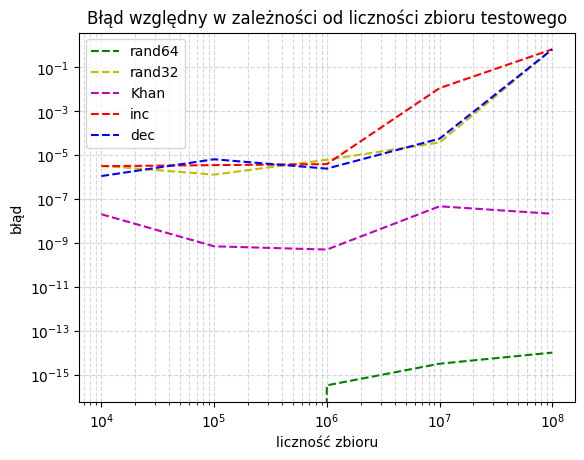

In [62]:
plt.loglog(n_array, abs(accumulators_array_a-true_sums)/true_sums, 'g--', label='rand64')
plt.loglog(n_array, abs(accumulators_array_b-true_sums)/true_sums, 'y--', label='rand32')
plt.loglog(n_array, abs(accumulators_array_c-true_sums)/true_sums, 'm--', label='Kahan')
plt.loglog(n_array, abs(accumulators_array_d-true_sums)/true_sums, 'r--', label='inc')
plt.loglog(n_array, abs(accumulators_array_e-true_sums)/(true_sums), 'b--', label='dec')
plt.title("Błąd względny w zależności od liczności zbioru testowego")
plt.xlabel("liczność zbioru")
plt.ylabel("błąd")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()